In [2]:
print(df.shape)
print(df.columns)
print(df.info())

(5347, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 5347 entries, 0 to 5346
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       5347 non-null   str  
 1   type          5347 non-null   str  
 2   title         5347 non-null   str  
 3   director      5329 non-null   str  
 4   cast          5347 non-null   str  
 5   country       5346 non-null   str  
 6   date_added    5347 non-null   str  
 7   release_year  5347 non-null   int64
 8   rating        5347 non-null   str  
 9   duration      5347 non-null   str  
 10  listed_in     5347 non-null   str  
 11  description   5347 non-null   str  
dtypes: int64(1), str(11)
memory usage: 501.4 KB
None


In [3]:
print(df.isnull().sum())

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

show_id          0
type             0
title            0
director        18
cast             0
country          1
date_added       0
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


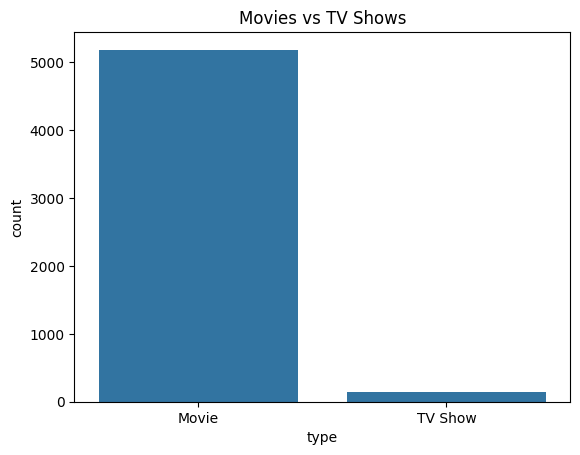

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")
plt.show()

This graph shows that Netflix has more Movies than TV Shows.

The analysis indicates that Movies are the dominant content type on the Netflix platform.

The data suggests that Netflix mainly focuses on movie-based entertainment.

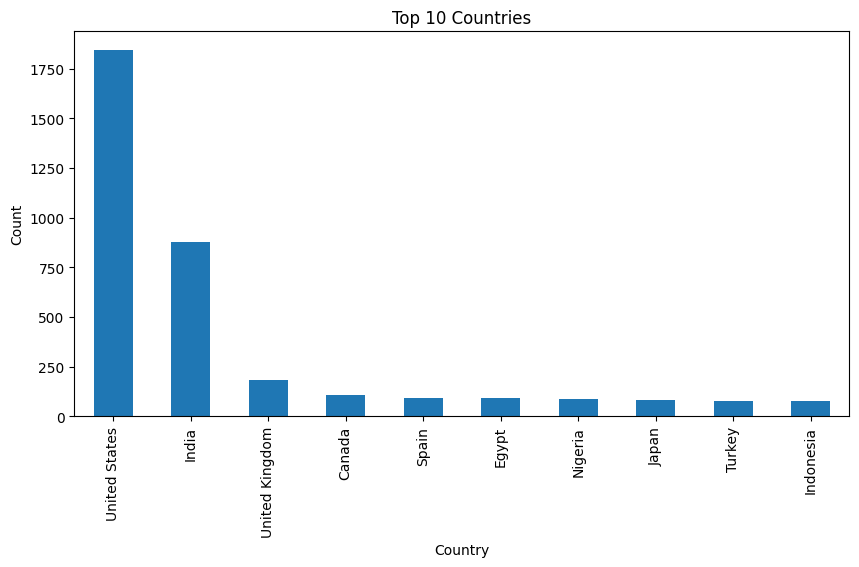

In [7]:
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_country.plot(kind='bar')

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

This graph shows that the United States has the highest amount of Netflix content.

The analysis indicates that the USA is the leading content producer on Netflix.

The data suggests that Netflix heavily relies on content from the United States.

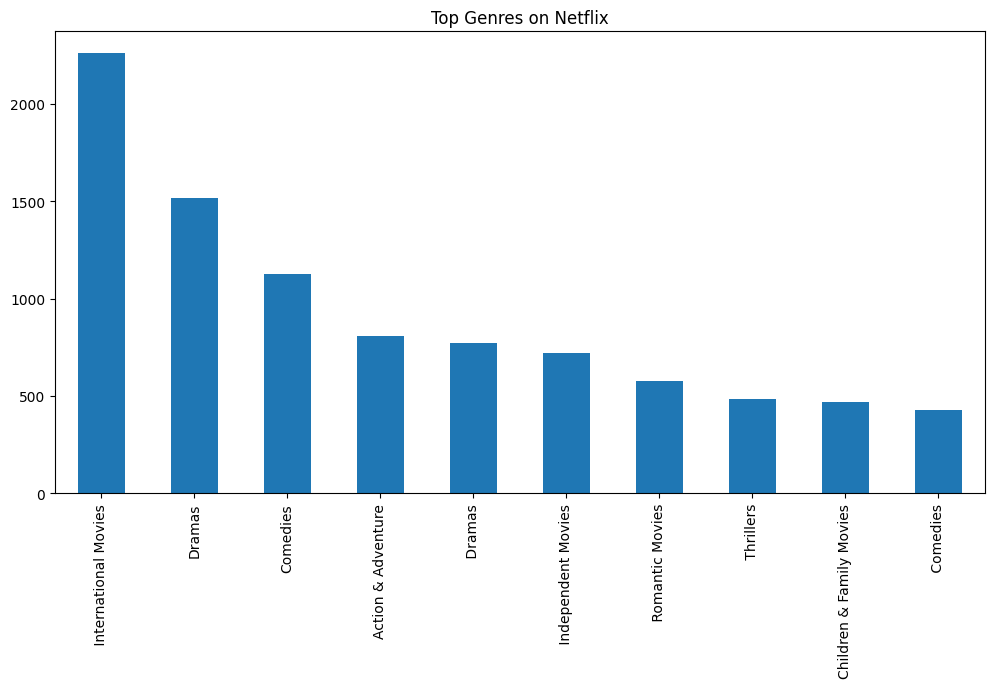

In [8]:
genres = df['listed_in'].str.split(',', expand=True).stack()

plt.figure(figsize=(12,6))

genres.value_counts().head(10).plot(kind='bar')

plt.title("Top Genres on Netflix")

plt.show()

This graph shows that Drama and International Movies are the most popular genres on Netflix.

The analysis indicates that viewers prefer Drama-related and global content.

The data suggests that Netflix focuses strongly on diverse entertainment categories.

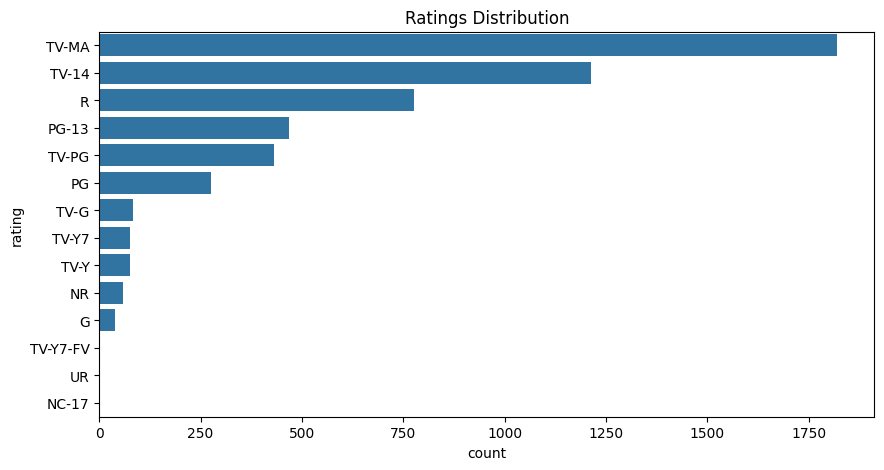

In [9]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Ratings Distribution")

plt.show()

This graph shows that TV-MA and TV-14 are the most common ratings on Netflix.

The analysis indicates that Netflix mainly contains content for teens and adults.

The data suggests that Netflix focuses more on mature audience entertainment.


C:\Users\acer\AppData\Local\Temp\ipykernel_13732\408496021.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'])


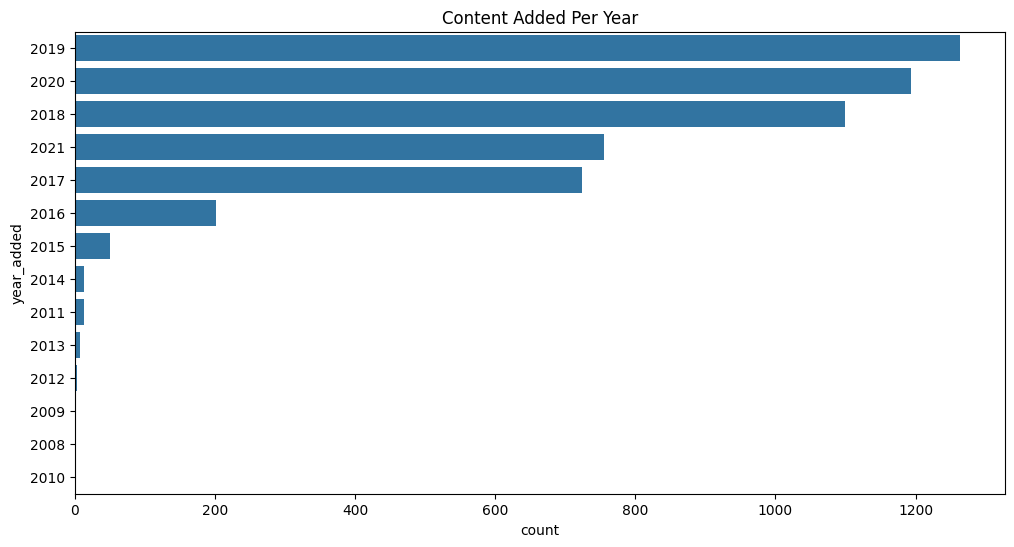

In [10]:
df['date_added'] = pd.to_datetime(df['date_added'])

df['year_added'] = df['date_added'].dt.year

plt.figure(figsize=(12,6))

sns.countplot(
    y='year_added',
    data=df,
    order=df['year_added'].value_counts().index
)

plt.title("Content Added Per Year")

plt.show()

This graph shows a rapid increase in Netflix content between 2018 and 2020.

The analysis indicates that Netflix expanded its content library significantly during recent years.

The data suggests that Netflix experienced major growth in content production and distribution.

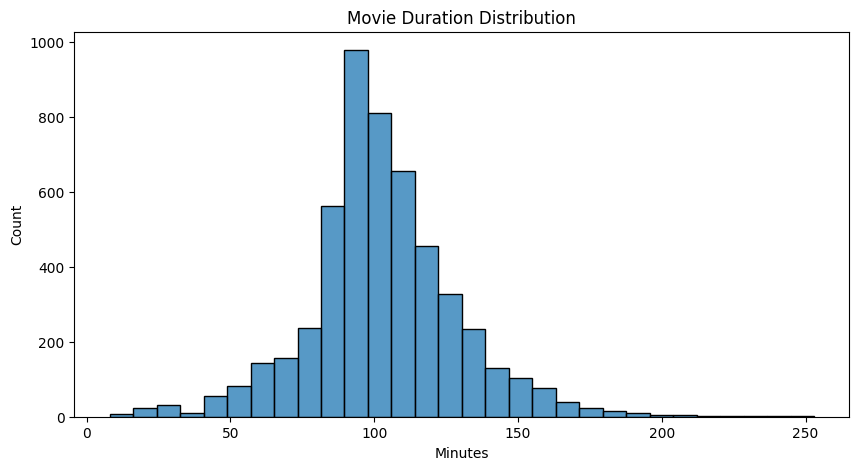

In [11]:
movies = df[df['type'] == 'Movie']

movies['duration'] = movies['duration'].str.replace(' min', '')

movies['duration'] = movies['duration'].astype(int)

plt.figure(figsize=(10,5))

sns.histplot(movies['duration'], bins=30)

plt.title("Movie Duration Distribution")

plt.xlabel("Minutes")

plt.show()

This graph shows that most Netflix movies have a duration between 80 and 120 minutes.

The analysis indicates that medium-length movies are more common on Netflix.

The data suggests that Netflix prefers standard movie durations for better audience engagement.